# ⚡ TSDynamics in an Hour

**A one-sitting, hands-on tour of the [TSDynamics](https://github.com/El3ssar/TSDynamics)
library** — for the workshop at the *Max Planck Institute for the Physics of Complex Systems*.

You already know nonlinear dynamics. In the next hour you'll learn to *do* it with this library:
integrate a system, measure chaos, draw a bifurcation diagram, build your own model, tell chaos
from noise in a measured signal, and animate an attractor — each in a handful of lines.

**How to use this notebook:** read a cell, run it (`Shift+Enter`), look at the result. Wherever you
see **▶ Try it**, change a number and re-run — that's the whole point. Nothing here takes more than
a few seconds to compute.

*Estimated time: ~60 minutes. Want the deep dive afterwards? A full 9-notebook version lives on the
[`main` branch](https://github.com/El3ssar/tsdynamics-workshop).*

In [1]:
# Setup — on Google Colab this installs the library on first run (~30 s); locally it's a no-op.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly"], check=True)

try:  # embed figures inline (this is what makes traj.plot() show up)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts

print("tsdynamics", ts.__version__, "— ready.")

tsdynamics 5.3.1 — ready.


## 1 · See a strange attractor

The whole library follows one rhythm: **pick a system → integrate it → get a `Trajectory` → look at it.**
Here is the Lorenz system, the icon of chaos, in two lines.

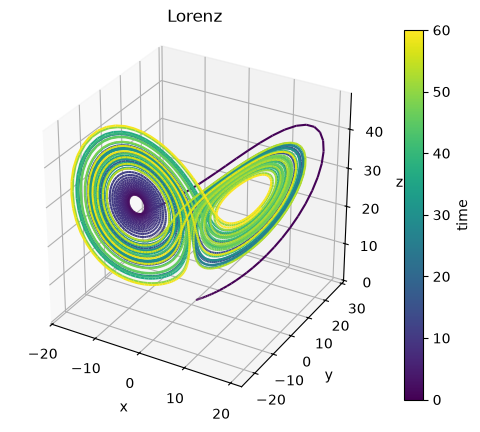

In [2]:
traj = ts.Lorenz().integrate(final_time=60.0, dt=0.01)
traj.plot(kind="phase_portrait_3d", color_by="time")   # returns a figure; it renders inline

`traj` holds the data: `traj.y` is the `(steps, 3)` array of states, `traj.t` the times, and — because
Lorenz names its coordinates — `traj["x"]` gives you a single channel. The colour above runs along time.

**▶ Try it.** The library ships **154 systems**. Swap `Lorenz` below for another 3-D attractor —
try `Aizawa`, `Thomas`, `Halvorsen`, `Chen`, or `Dadras` — and re-run.

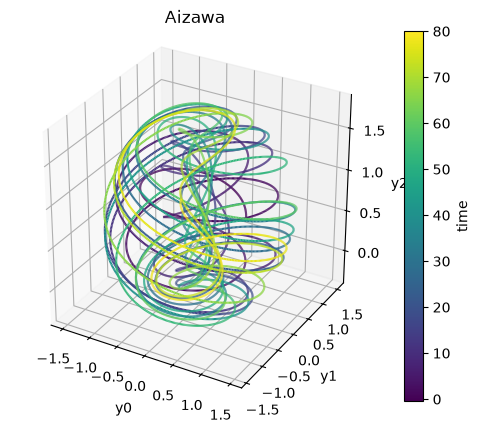

In [3]:
name = "Aizawa"          # <-- change me
getattr(ts, name)().integrate(final_time=80.0, dt=0.005).plot(kind="phase_portrait_3d", color_by="time")

Maps work the same way with `.iterate()`. One line gives you the Hénon attractor's dust:

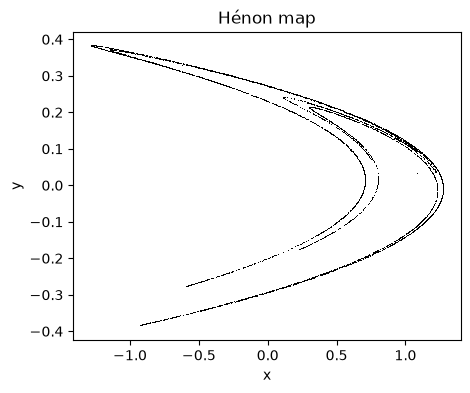

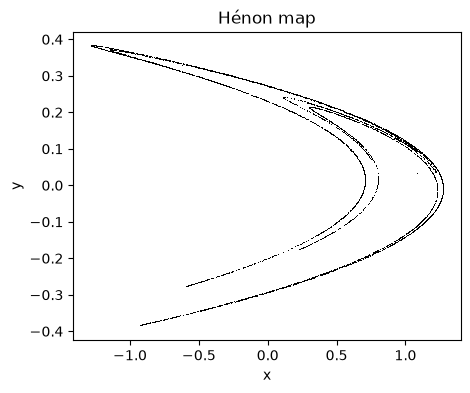

In [4]:
h = ts.Henon().iterate(steps=6000, ic=[0.1, 0.1])
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(h.y[:, 0], h.y[:, 1], ",k")
ax.set_title("Hénon map"); ax.set_xlabel("x"); ax.set_ylabel("y")
fig

## 2 · Chaos, as a single number

What makes an attractor *strange*? Sensitive dependence on initial conditions — a **positive Lyapunov
exponent**. The library computes the whole spectrum for you.

In [5]:
spectrum = ts.Lorenz().lyapunov_spectrum(final_time=200.0, dt=0.02)
print("Lyapunov spectrum:", np.round(spectrum, 3))
print("Largest exponent :", round(float(spectrum[0]), 3), "→ positive ⇒ chaos")
print("Kaplan–Yorke dim :", round(float(ts.kaplan_yorke_dimension(spectrum)), 3))

Lyapunov spectrum: [ 9.0600e-01 -2.0000e-03 -1.4571e+01]
Largest exponent : 0.906 → positive ⇒ chaos
Kaplan–Yorke dim : 2.062


The signature `[+, 0, −]` is the fingerprint of a chaotic flow: one stretching direction, one neutral
(along the flow), one strongly contracting. The **Kaplan–Yorke dimension** (~2.06) says the attractor
is a fractal sheet — thicker than a surface, thinner than a volume.

**▶ Try it.** Is the Rössler system chaotic? Compute *its* spectrum — you're looking for a positive
leading exponent.

In [6]:
ross_spectrum = ts.Rossler().lyapunov_spectrum(final_time=400.0, dt=0.05)
print("Rössler spectrum:", np.round(ross_spectrum, 3), "→ leading exponent > 0 ⇒ yes, chaotic")

Rössler spectrum: [ 6.200e-02  3.000e-03 -5.398e+00] → leading exponent > 0 ⇒ yes, chaotic


## 3 · The road to chaos

How does a system *become* chaotic? The logistic map $x_{n+1} = r\,x_n(1-x_n)$ answers with the most
famous picture in nonlinear dynamics — a **bifurcation diagram**. One call sweeps the parameter `r` and
records where the orbit settles.

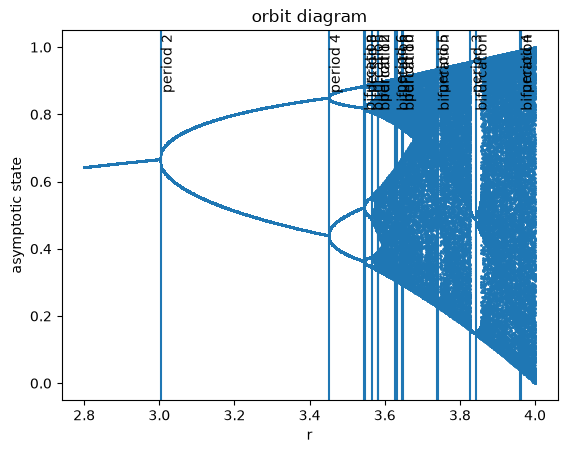

In [7]:
bif = ts.bifurcation_diagram(ts.Logistic(), "r", np.linspace(2.8, 4.0, 800),
                             n=180, transient=400)
bif.plot()

Read it left to right: a single stable state, then period-2, period-4, period-8 … a **period-doubling
cascade** that accumulates into chaos near $r \approx 3.57$, shot through with white "windows" of order.

**▶ Try it.** Zoom in. Change the range below to `np.linspace(3.5, 3.6, 800)` to see the cascade up close,
or `np.linspace(3.82, 3.86, 800)` to land inside the famous period-3 window.

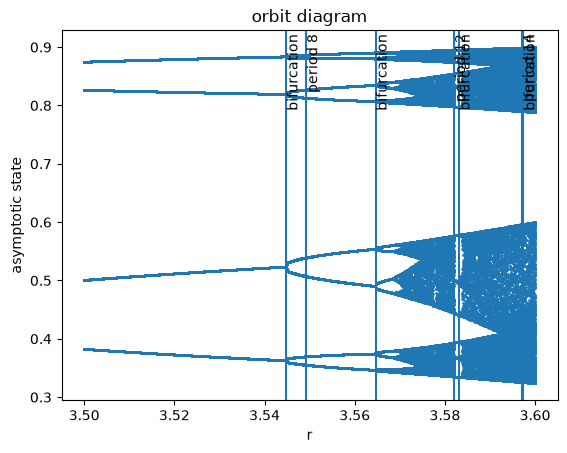

In [8]:
ts.bifurcation_diagram(ts.Logistic(), "r", np.linspace(3.5, 3.6, 800), n=200, transient=500).plot()

## 4 · Build your own system

The catalogue is nice, but your research has its *own* equations. Defining a system is a tiny class.
Here is the **Van der Pol oscillator** $\ddot{x} = \mu(1-x^2)\dot{x} - x$ from scratch:

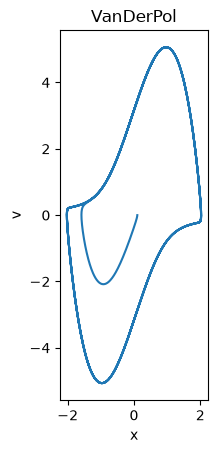

In [9]:
import symengine as se   # use symengine functions (se.sin, se.cos, ...) inside _equations

class VanDerPol(ts.ContinuousSystem):
    params = {"mu": 3.0}            # parameters you can sweep
    dim = 2                         # REQUIRED: state dimension
    variables = ("x", "v")          # names → traj["x"]
    default_ic = [0.1, 0.0]

    @staticmethod                   # _equations is a staticmethod with keyword-only params
    def _equations(y, t, *, mu):
        x, v = y(0), y(1)           # read the state via y(0), y(1), ...
        return [v, mu * (1 - x**2) * v - x]

vdp = VanDerPol().integrate(final_time=40.0, dt=0.01)
vdp.plot(components=["x", "v"])     # 2 components → phase portrait; watch it settle onto the limit cycle

Three rules and you're done: declare `dim`, make `_equations` a `@staticmethod` with keyword-only
parameters, and use `symengine` functions (not `numpy`) so the engine can compile it. That's the whole
contract — and the library now gives your system integration, Lyapunov exponents, bifurcations, plots…
everything, for free.

**▶ Try it.** Change `mu` below (try `0.5`, `2`, `6`) and watch how sharply the relaxation oscillation snaps.

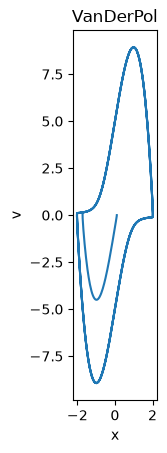

In [10]:
VanDerPol().with_params(mu=6.0).integrate(final_time=40.0, dt=0.01).plot(components=["x", "v"])

## 5 · Detective work: is it chaos, or just noise?

In the lab you rarely get equations — you get a **wiggly signal**. Can you tell whether it's low-dimensional
deterministic chaos (predictable, controllable) or irreducible noise? You can, *from the data alone*.

A colleague hands you this one scalar time series. (We built it from a Lorenz coordinate, but play along —
pretend you don't know that.)

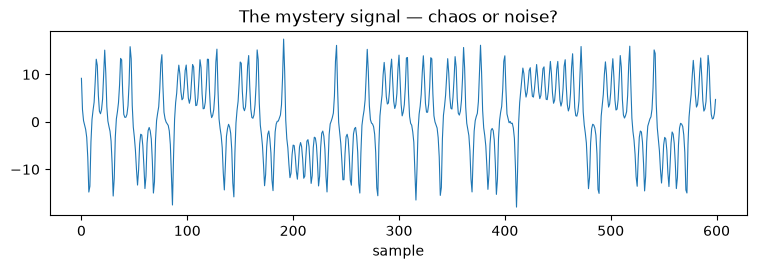

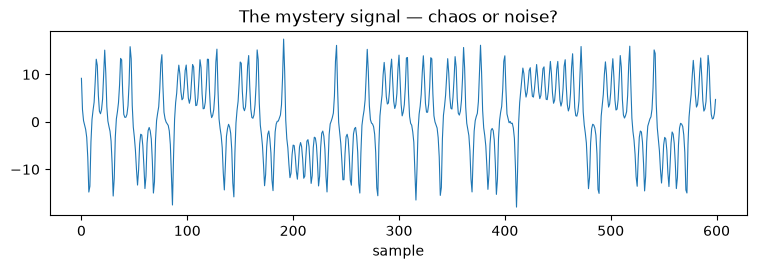

In [11]:
rng = np.random.default_rng(0)
_lor = ts.Lorenz().integrate(final_time=300.0, dt=0.01)
mystery = _lor.y[_lor.t > 20.0, 0][::10]                    # one channel, subsampled
mystery = mystery + 0.02 * np.std(mystery) * rng.standard_normal(mystery.shape)  # measurement noise

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot(mystery[:600], lw=0.8); ax.set_title("The mystery signal — chaos or noise?"); ax.set_xlabel("sample")
fig

**Step 1 — reconstruct the hidden attractor.** Takens' theorem says a single channel, delayed against
itself, re-draws the underlying dynamics. The library finds a good delay for you and builds the embedding.

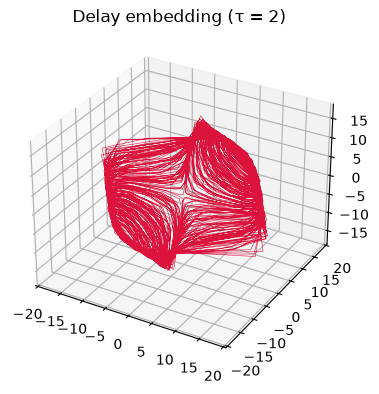

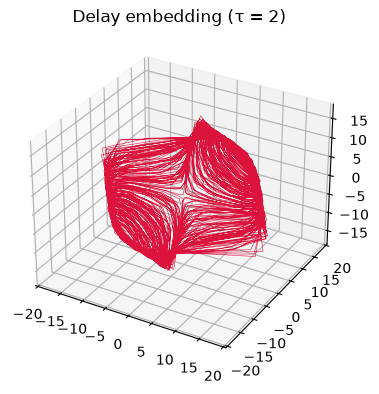

In [12]:
from tsdynamics.analysis.embedding import optimal_delay, embed

tau = int(optimal_delay(mystery).value)
emb = np.asarray(embed(mystery, dimension=3, delay=tau))
fig = plt.figure(figsize=(5.2, 4.4)); ax = fig.add_subplot(111, projection="3d")
ax.plot(emb[:, 0], emb[:, 1], emb[:, 2], lw=0.4, color="crimson")
ax.set_title(f"Delay embedding (τ = {tau})"); fig

That is not a fuzzball — it's a **structured object**. Strong hint of determinism. But let's *prove* it.

**Step 2 — put it on trial.** A **surrogate test** builds many random signals with the *same power spectrum*
as the data but no nonlinear structure, and checks whether the data is more predictable than they are.
If yes, the determinism is real.

In [13]:
verdict = ts.surrogate_test(mystery[:2500], statistic="prediction_error", method="iaaft", n=25, seed=1)
d = verdict.to_dict()
print(f"data more predictable than surrogates?  rejected = {d['rejected']}  (z = {d['z_score']:.1f})")
print("→ the null 'it's just linear noise' is REJECTED: this is deterministic chaos.")

data more predictable than surrogates?  rejected = True  (z = -75.3)
→ the null 'it's just linear noise' is REJECTED: this is deterministic chaos.


**The control.** Run the exact same test on genuine **colored noise** (an AR(1) process — it *also*
looks wiggly and broadband, but it is linear and stochastic) and the verdict flips: nothing to reject.

In [14]:
noise = np.zeros(2500)                       # AR(1): noise[i] = 0.9*noise[i-1] + white
eps = rng.standard_normal(2500)
for i in range(1, 2500):
    noise[i] = 0.9 * noise[i - 1] + eps[i]
dn = ts.surrogate_test(noise, statistic="prediction_error", method="iaaft", n=25, seed=1).to_dict()
print(f"AR(1) colored noise:  rejected = {dn['rejected']}  (z = {dn['z_score']:.1f})  → correctly cleared: not chaos")

AR(1) colored noise:  rejected = False  (z = 0.2)  → correctly cleared: not chaos


That contrast is the payoff: two signals that look alike to the eye, told apart rigorously by their
dynamics. (The library also has correlation dimension, Lyapunov-from-data, recurrence quantification and
more for the follow-up questions.)

## 6 · Make it move

Finally, the fun part. Any trajectory becomes an animation with one flag. This writes a GIF and shows it inline.

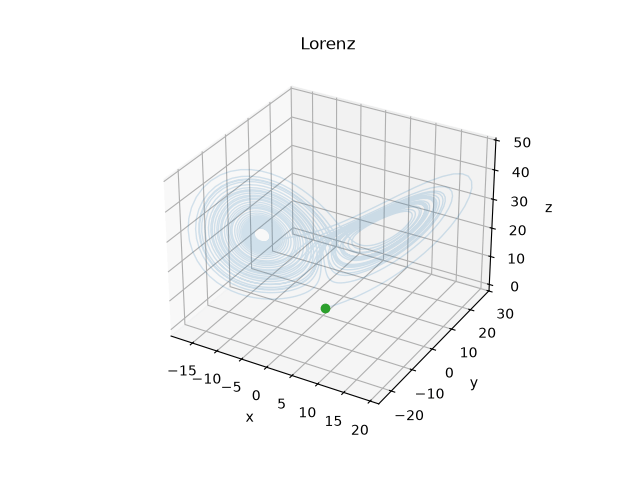

In [15]:
import os
from IPython.display import Image

os.makedirs("express_assets", exist_ok=True)
gif = "express_assets/lorenz.gif"
ts.Lorenz().integrate(final_time=40.0, dt=0.01).to_plot_spec(animate=True).save(gif, fps=20)
Image(filename=gif)

Swap `.save("lorenz.gif")` for `.save("lorenz.html")` and you get a self-contained, rotatable Plotly
animation instead — perfect for a talk or a webpage.

---
## That's the hour.

In ~60 minutes you have:

- **integrated** flows and maps and plotted their attractors,
- measured chaos with a **Lyapunov spectrum** and a fractal **dimension**,
- drawn a **bifurcation diagram** of the road to chaos,
- **built your own system** in six lines,
- told **chaos from noise** in a measured signal, and
- **animated** an attractor.

**Where next?** The full **9-notebook deep dive** — custom DDE/SDE models, Poincaré sections, fixed points
& stability, basins of attraction, tipping points, and a power-grid capstone — is on the
[`main` branch](https://github.com/El3ssar/tsdynamics-workshop). Docs live at
**https://el3ssar.github.io/TSDynamics/**.

Happy hunting. 🦋